# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Fairuz Arfan Abhipraya
- Email: fairuzarfan@student.ub.ac.id
- Id Dicoding: CDCC006D6Y2510

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan digunakan

In [4]:
url = "https://docs.google.com/spreadsheets/d/1_TPQP7Z-r-DSZFEnV50uJYevCZ07dTKfG3-EPHISgNs/export?format=csv"
df = pd.read_csv(url, sep=',')

print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
df.head()

Jumlah baris: 4424
Jumlah kolom: 37


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding


Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non

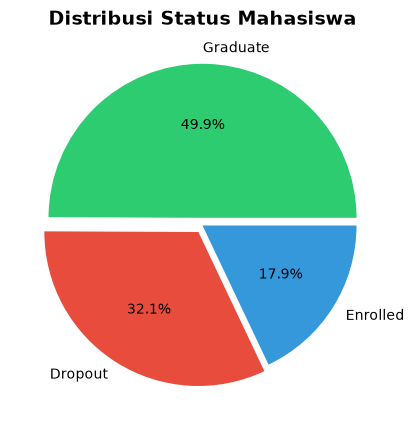

In [5]:
# 1. Informasi dataset
print("\nInformasi Dataset:")
df.info()

# 2. Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()

# 3. Cek Missing Values
print("\nDeteksi Missing Values")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase': missing_percent
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
else:
    print("Tidak ada missing values!")

# 4. Cek Duplikasi
print("\nDeteksi Duplikasi:")

duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")
print(f"Persentase duplikat: {(duplicate_count/len(df))*100:.2f}%")

if duplicate_count > 0:
    print("\nContoh data duplikat:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("Tidak ada data duplikat!")

# 5. Distribusi Target (Status)
print("\nDistribusi Target (Status):")

target_counts = df['Status'].value_counts()
print(target_counts)

# Visualisasi
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if x == 'Graduate' else '#e74c3c' if x == 'Dropout' else '#3498db' for x in target_counts.index]
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=colors, explode=(0.05, 0.05, 0))
plt.title('Distribusi Status Mahasiswa', fontweight='bold', fontsize=14)
plt.show()


## Data Preparation / Preprocessing

In [10]:
# 1. Filter Data hanya Dropout dan Graduate
print("\n1. Filter Data:")
df_filtered = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f"   Data awal: {len(df)} baris")
print(f"   Data setelah filter: {len(df_filtered)} baris")
print(f"   Data Enrolled yang dihapus: {len(df) - len(df_filtered)} baris")

print("\n   Distribusi status setelah filter:")
print(df_filtered['Status'].value_counts())

df_clean = df_filtered.copy()

# 2. Penanganan Missing Values
print("\n2. Penanganan Missing Values:")

for col in df_clean.columns:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"   {col}: diisi dengan median ({median_val:.2f})")
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   {col}: diisi dengan modus ({mode_val})")

print("\nMissing values berhasil ditangani!")

# 3. Penanganan Outlier
print("\n3. Penanganan Outlier:")

outlier_handled = []
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    
    if outlier_count > 0:
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
        outlier_handled.append({
            'Kolom': col,
            'Jumlah Outlier': outlier_count,
            'Persentase': f'{(outlier_count/len(df_clean))*100:.2f}%'
        })
        print(f"   {col}: {outlier_count} outlier ditangani")

if outlier_handled:
    print("\n   Ringkasan penanganan outlier:")
    print(pd.DataFrame(outlier_handled).to_string(index=False))
else:
    print("   Tidak ada outlier yang terdeteksi!")

print("\nOutlier berhasil ditangani!")

# 4. Penanganan Duplikasi
print("\n4. Penanganan Duplikasi:")
duplicate_before = df_clean.duplicated().sum()
if duplicate_before > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"   Menghapus {duplicate_before} data duplikat")
else:
    print("   Tidak ada data duplikat")

# 5. Encode Target
print("\n5. Encode Target:")
le_target = LabelEncoder()
df_clean['Status_encoded'] = le_target.fit_transform(df_clean['Status'])
print(f"   Encoding Status:")
for i, status in enumerate(le_target.classes_):
    print(f"      {status} -> {i}")

# 6. Pilih fitur untuk modeling
print("\n6. Seleksi Fitur:")
columns_to_drop = ['Status']
feature_columns = [col for col in df_clean.columns if col not in ['Status', 'Status_encoded']]
X = df_clean[feature_columns]
y = df_clean['Status_encoded']

print(f"   Jumlah fitur: {X.shape[1]}")
print(f"   Jumlah sampel: {X.shape[0]}")
print(f"   Distribusi target: {pd.Series(y).value_counts().sort_index().to_dict()}")

# 7. Split data
print("\n7. Split data Train-Test:")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# 8. Encoding fitur kategorikal
print("\n8. Encoding fitur kategorikal:")
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print(f"   {len(categorical_cols)} fitur kategorikal berhasil di-encode")

# 9. Scaling fitur numerik
print("\n9. Scaling fitur numerik:")
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

print(f"   {len(numeric_cols)} fitur numerik berhasil di-scaling")

# 10. Feature Selection
print("\n10. Feature Selection:")
selector = SelectKBest(f_classif, k=30)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X_train_scaled.columns[selector.get_support()].tolist()
print(f"   {len(selected_features)} fitur terpilih dari {X_train_scaled.shape[1]} fitur")


1. Filter Data:
   Data awal: 4424 baris
   Data setelah filter: 3630 baris
   Data Enrolled yang dihapus: 794 baris

   Distribusi status setelah filter:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

2. Penanganan Missing Values:

Missing values berhasil ditangani!

3. Penanganan Outlier:
   Marital_status: 431 outlier ditangani
   Application_order: 468 outlier ditangani
   Course: 381 outlier ditangani
   Daytime_evening_attendance: 408 outlier ditangani
   Previous_qualification: 611 outlier ditangani
   Previous_qualification_grade: 146 outlier ditangani
   Nacionality: 86 outlier ditangani
   Mothers_occupation: 137 outlier ditangani
   Fathers_occupation: 134 outlier ditangani
   Admission_grade: 71 outlier ditangani
   Educational_special_needs: 40 outlier ditangani
   Debtor: 413 outlier ditangani
   Tuition_fees_up_to_date: 486 outlier ditangani
   Age_at_enrollment: 389 outlier ditangani
   International: 86 outlier ditangani
   Curricular_units_1st_se

## Exploratory Data Analysis (EDA)


1. Analisis Target:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

2. Analisis berdasarkan Gender:
Status     Dropout  Graduate
Perempuan      720      1661
Laki-laki      701       548

🔍 Cek nilai unik pada kolom Debtor:
[0]

Jumlah baris debtor_status: 1
⚠️ Hanya ada 1 nilai pada kolom Debtor, menambahkan baris dummy untuk visualisasi

Debtor Status setelah perbaikan:
Status           Dropout  Graduate
Tidak Berhutang     1421      2209
Berhutang              0         0


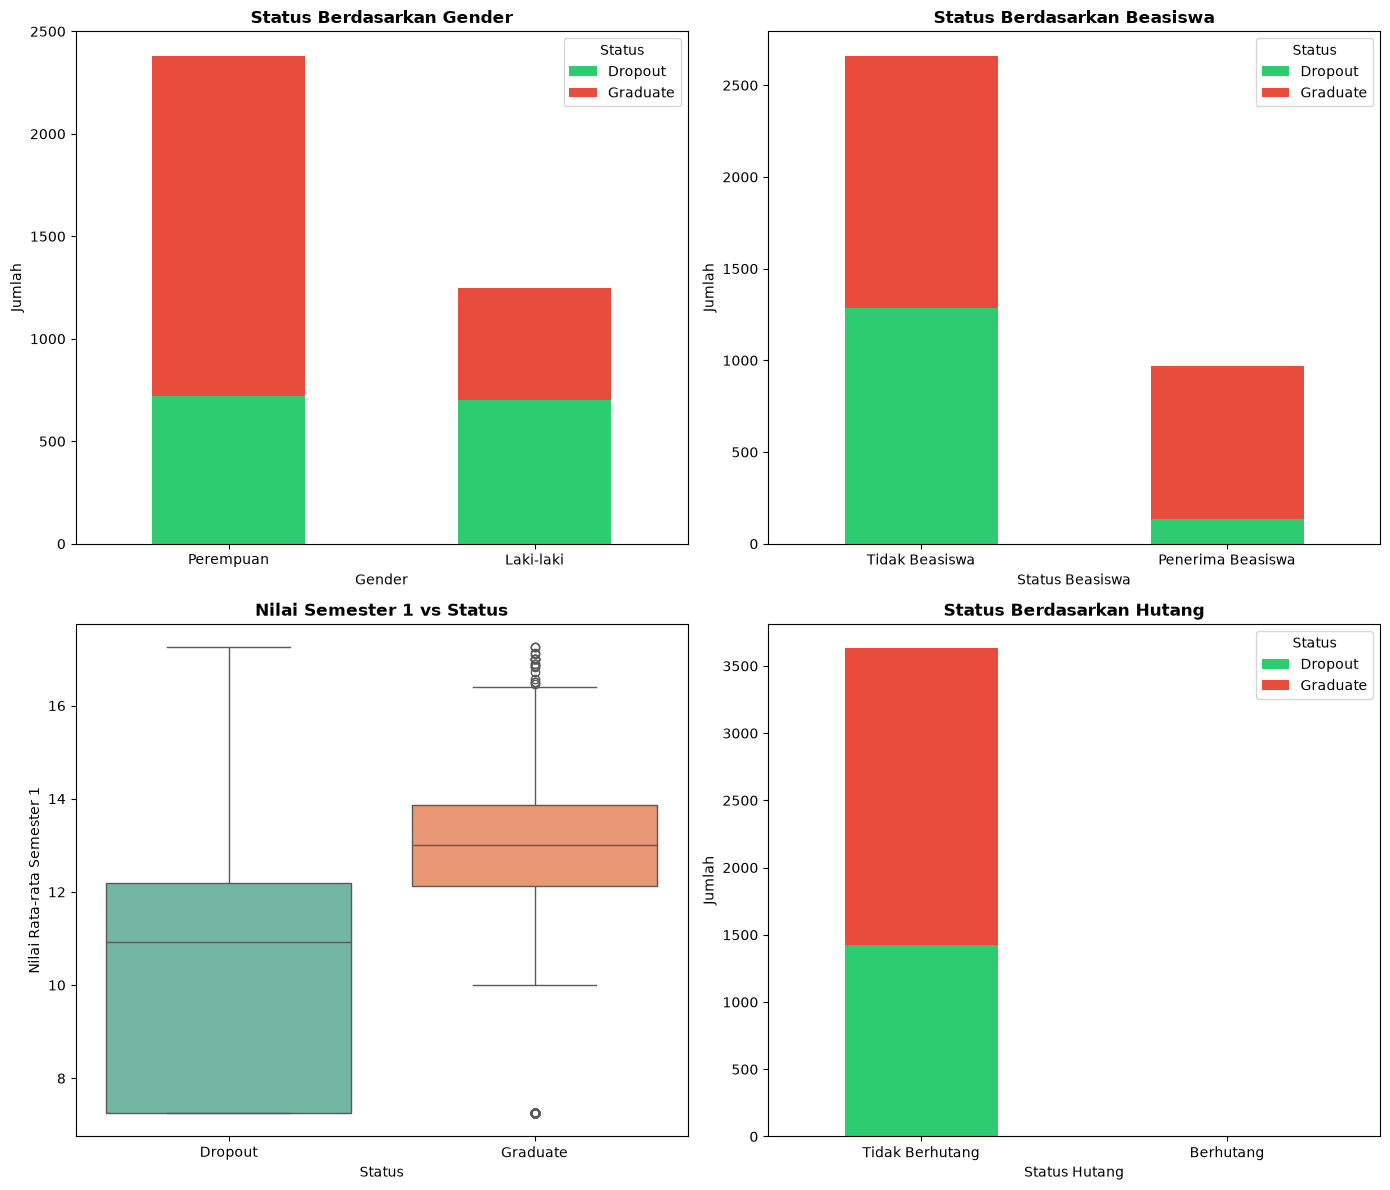

In [14]:
# 1. Analisis Target
print("\n1. Analisis Target:")
print(df_clean['Status'].value_counts())

# 2. Analisis berdasarkan Gender
print("\n2. Analisis berdasarkan Gender:")
gender_status = pd.crosstab(df_clean['Gender'], df_clean['Status'])
gender_status.index = ['Perempuan', 'Laki-laki']
print(gender_status)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gender vs Status
gender_status.plot(kind='bar', stacked=True, ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Status Berdasarkan Gender', fontweight='bold')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Jumlah')
axes[0,0].legend(title='Status')
axes[0,0].tick_params(axis='x', rotation=0)

# Beasiswa vs Status
scholarship_status = pd.crosstab(df_clean['Scholarship_holder'], df_clean['Status'])
scholarship_status.index = ['Tidak Beasiswa', 'Penerima Beasiswa']
scholarship_status.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Status Berdasarkan Beasiswa', fontweight='bold')
axes[0,1].set_xlabel('Status Beasiswa')
axes[0,1].set_ylabel('Jumlah')
axes[0,1].legend(title='Status')
axes[0,1].tick_params(axis='x', rotation=0)

# Nilai Semester 1 vs Status
sns.boxplot(data=df_clean, x='Status', y='Curricular_units_1st_sem_grade', 
            palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Nilai Semester 1 vs Status', fontweight='bold')
axes[1,0].set_ylabel('Nilai Rata-rata Semester 1')

# Hutang vs Status - Cek unique values terlebih dahulu
print("\n🔍 Cek nilai unik pada kolom Debtor:")
print(df_clean['Debtor'].unique())

# Crosstab dengan handling jika hanya ada 1 nilai
debtor_status = pd.crosstab(df_clean['Debtor'], df_clean['Status'])

# Cek jumlah baris sebelum mengubah index
print(f"\nJumlah baris debtor_status: {len(debtor_status)}")

if len(debtor_status) == 1:
    # Jika hanya ada 1 nilai, tambahkan baris dummy untuk visualisasi
    print("⚠️ Hanya ada 1 nilai pada kolom Debtor, menambahkan baris dummy untuk visualisasi")
    
    # Buat index yang sesuai
    if 0 in debtor_status.index:
        debtor_status.index = ['Tidak Berhutang']
        # Tambahkan baris 'Berhutang' dengan nilai 0
        dummy_row = pd.DataFrame([[0, 0]], columns=debtor_status.columns, index=['Berhutang'])
        debtor_status = pd.concat([debtor_status, dummy_row])
    else:
        debtor_status.index = ['Berhutang']
        dummy_row = pd.DataFrame([[0, 0]], columns=debtor_status.columns, index=['Tidak Berhutang'])
        debtor_status = pd.concat([debtor_status, dummy_row])
else:
    # Jika ada 2 nilai, beri label yang sesuai
    debtor_status.index = ['Tidak Berhutang', 'Berhutang']

print("\nDebtor Status setelah perbaikan:")
print(debtor_status)

# Plot
debtor_status.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Status Berdasarkan Hutang', fontweight='bold')
axes[1,1].set_xlabel('Status Hutang')
axes[1,1].set_ylabel('Jumlah')
axes[1,1].legend(title='Status')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Modeling

In [15]:
# Pendefinisan model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

# Train dan evaluasi
results = []
best_model = None
best_accuracy = 0

print("\nTraining models...\n")

for name, model in models.items():
    print(f"📊 {name}")
    model.fit(X_train_selected, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_selected)
    
    # Metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name
    
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   F1-Score: {f1:.4f}\n")

# Tampilkan hasil
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n" + "=" * 60)
print("HASIL EVALUASI SEMUA MODEL")
print("=" * 60)
print(results_df.to_string(index=False))
print(f"\n✅ Model Terbaik: {best_model_name} dengan Accuracy: {best_accuracy:.4f}")

# Hyperparameter Tuning untuk model terbaik
print("\n" + "=" * 60)
print(f"HYPERPARAMETER TUNING UNTUK {best_model_name}")
print("=" * 60)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
else:
    param_grid = {
        'C': [0.1, 1, 10],
        'max_iter': [1000, 2000]
    }

grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
print("Menjalankan Grid Search...")
grid_search.fit(X_train_selected, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Model terbaik setelah tuning
best_model_tuned = grid_search.best_estimator_
y_pred_tuned = best_model_tuned.predict(X_test_selected)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Test accuracy after tuning: {accuracy_tuned:.4f}")

# Simpan model
print("\n" + "=" * 60)
print("MENYIMPAN MODEL")
print("=" * 60)

if not os.path.exists('model'):
    os.makedirs('model')

joblib.dump(best_model_tuned, 'model/best_model.pkl')
print("✅ best_model.pkl disimpan")

joblib.dump(scaler, 'model/scaler.pkl')
print("✅ scaler.pkl disimpan")

joblib.dump(selector, 'model/selector.pkl')
print("✅ selector.pkl disimpan")

joblib.dump(le_target, 'model/encoder_target.pkl')
print("✅ encoder_target.pkl disimpan")

for col, le in label_encoders.items():
    joblib.dump(le, f'model/encoder_{col}.pkl')
print(f"✅ {len(label_encoders)} encoder fitur disimpan")

# Simpan selected features
with open('model/selected_features.txt', 'w') as f:
    for feature in selected_features:
        f.write(f"{feature}\n")
print("✅ selected_features.txt disimpan")


Training models...

📊 Logistic Regression
   Accuracy: 0.8967
   F1-Score: 0.8956

📊 K-Neighbors
   Accuracy: 0.8444
   F1-Score: 0.8392

📊 Decision Tree
   Accuracy: 0.8760
   F1-Score: 0.8750

📊 Random Forest
   Accuracy: 0.8912
   F1-Score: 0.8891

📊 Gradient Boosting
   Accuracy: 0.8898
   F1-Score: 0.8881

📊 XGBoost
   Accuracy: 0.8898
   F1-Score: 0.8882


HASIL EVALUASI SEMUA MODEL
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.896694   0.897265 0.896694  0.895647
      Random Forest  0.891185   0.894667 0.891185  0.889139
            XGBoost  0.889807   0.891425 0.889807  0.888235
  Gradient Boosting  0.889807   0.891773 0.889807  0.888128
      Decision Tree  0.876033   0.875758 0.876033  0.875041
        K-Neighbors  0.844353   0.851553 0.844353  0.839226

✅ Model Terbaik: Logistic Regression dengan Accuracy: 0.8967

HYPERPARAMETER TUNING UNTUK Logistic Regression
Menjalankan Grid Search...
Best parameters: {'C': 0.1, 'max_iter': 1000}
Bes

## Evaluation

EVALUATION

1. CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Dropout       0.90      0.81      0.85       284
    Graduate       0.89      0.94      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726


2. CONFUSION MATRIX
[[231  53]
 [ 26 416]]


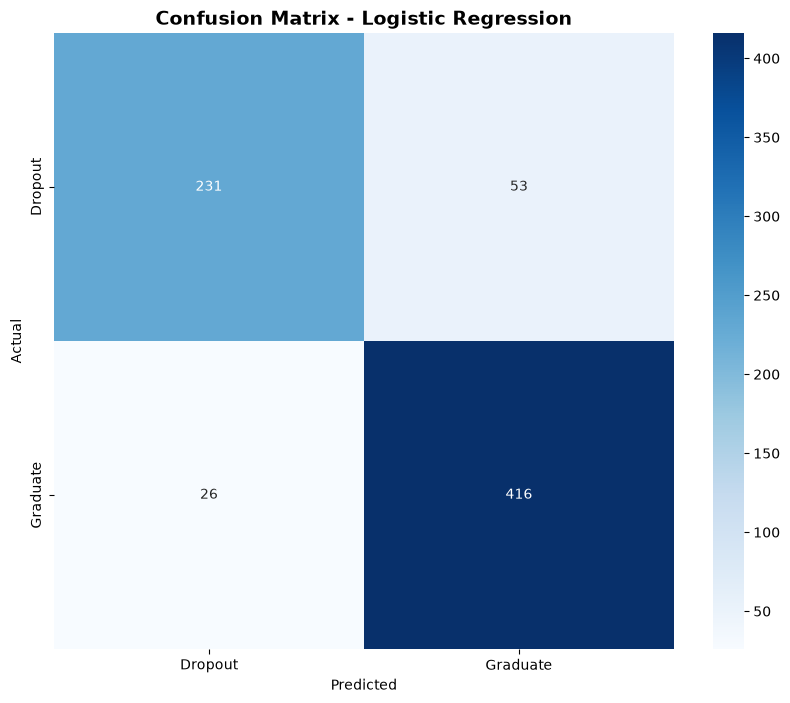


3. PERFORMANCE METRICS
Model: Logistic Regression
Accuracy: 0.8912
Precision (weighted): 0.8916
Recall (weighted): 0.8912
F1-Score (weighted): 0.8901

4. CROSS-VALIDATION
CV Scores: [0.87091222 0.90533563 0.88640275 0.89328744 0.90172414]
Mean CV Score: 0.8915
Std CV Score: 0.0122

6. ANALISIS KESALAHAN PREDIKSI
Jumlah prediksi salah: 79
Persentase error: 10.88%

Contoh data yang salah prediksi (5 data pertama):
  Index 25: Actual=Graduate, Predicted=Dropout
  Index 34: Actual=Dropout, Predicted=Graduate
  Index 42: Actual=Dropout, Predicted=Graduate
  Index 47: Actual=Dropout, Predicted=Graduate
  Index 55: Actual=Graduate, Predicted=Dropout


In [ ]:
# 1. Classification Report
print("\n1. Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le_target.classes_))

# 2. Confusion Matrix
print("\n2. Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_tuned)
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. Performance Metrics
print("\n3. Performance Metrics:")
print(f"Model: {best_model_name}")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

# 4. Cross-Validation
print("\n4. Cross-Validation:")
cv_scores = cross_val_score(best_model_tuned, X_train_selected, y_train, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

# 5. Feature Importance  
if hasattr(best_model_tuned, 'feature_importances_'):
    print("\n5. TOP 10 FEATURE IMPORTANCE")
    importances = best_model_tuned.feature_importances_
    feature_names = selected_features
    
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Visualisasi
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(10)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# 6. Analisis Kesalahan Prediksi
print("\n6. Analisis Kesalahan Prediksi:")
misclassified = y_test != y_pred_tuned
misclassified_indices = np.where(misclassified)[0]

print(f"Jumlah prediksi salah: {len(misclassified_indices)}")
print(f"Persentase error: {len(misclassified_indices)/len(y_test)*100:.2f}%")

if len(misclassified_indices) > 0:
    print("\nContoh data yang salah prediksi (5 data pertama):")
    for idx in misclassified_indices[:5]:
        actual = le_target.inverse_transform([y_test.iloc[idx]])[0]
        predicted = le_target.inverse_transform([y_pred_tuned[idx]])[0]
        print(f"  Index {idx}: Actual={actual}, Predicted={predicted}")